# Phase6: Portfolio Construction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Dict, Callable
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import cvxpy as cp

In [2]:
%run "./Factor Combination.ipynb"

X_rank shape: (4391, 21252)
close_panel shape: (4391, 1771)
R_fwd_s shape: (4391, 1771)
sample_mask true ratio: 0.2741563289522059
k_min factors required: 6


,000005,000006,000008,000009,000012,000016,000021,000025,000027,000028,...,688692,688702,688709,688728,688772,688777,688778,688779,688819,689009
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-29,NaN,0.015326,NaN,NaN,NaN,-0.018182,NaN,NaN,NaN,0.053257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-30,NaN,-0.018868,NaN,NaN,NaN,-0.003472,NaN,NaN,NaN,-0.063205,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-31,NaN,-0.016538,NaN,NaN,NaN,-0.047619,NaN,NaN,NaN,0.000964,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-02-01,NaN,0.075479,NaN,NaN,NaN,0.075610,NaN,NaN,NaN,0.082330,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-02-04,NaN,-0.016364,NaN,NaN,NaN,0.021542,NaN,NaN,NaN,0.006673,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,000005,000006,000008,000009,000012,000016,000021,000025,000027,000028,...,688692,688702,688709,688728,688772,688777,688778,688779,688819,689009
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-29,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2008-01-30,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2008-01-31,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2008-02-01,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2008-02-04,False,True,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


Equal-weight combo IC mean/std/ICIR: -0.05192731736876554 0.15107209638883876 -0.34372540402902585


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


...

/Users/apple/Documents/GitHub/Systematic-Equities/ml_utilities.py:75: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  X_long = X.stack(level=ticker_column)


Long panel shape: (1022267, 13) (rows x (features + y))
#features: 12  #dates: 2820


,model,ic_mean,ic_std,ic_ir,ic_n,ls_mean,ls_std,ls_ir,ls_n
6,Huber,0.074123,0.136087,0.544670,2760.0,0.001939,0.009116,0.212715,2760.0
3,Ridge(1.0),0.053040,0.142084,0.373302,2760.0,0.001717,0.009367,0.183273,2760.0
0,OLS,0.053040,0.142084,0.373302,2760.0,0.001717,0.009367,0.183273,2760.0
1,Ridge(1e-2),0.053040,0.142084,0.373302,2760.0,0.001717,0.009367,0.183273,2760.0
2,Ridge(1e-1),0.053040,0.142084,0.373301,2760.0,0.001717,0.009367,0.183273,2760.0
5,Lasso(0.001),0.016866,0.064331,0.262178,2760.0,0.000618,0.006213,0.099482,2760.0
4,"ElasticNet(0.01,0.5)",0.000000,0.000000,NaN,2760.0,-0.000015,0.005567,-0.002744,2760.0


S_huber shape: (2760, 1253)


,000008,000009,000012,000021,000025,000027,000028,000030,000031,000032,...,688567,688578,688617,688690,688772,688777,688778,688779,688819,689009
2013-08-30,NaN,NaN,NaN,NaN,NaN,NaN,-0.001283,NaN,0.000277,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-02,NaN,NaN,NaN,NaN,NaN,NaN,-0.002094,NaN,0.000634,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-03,NaN,NaN,NaN,NaN,NaN,NaN,-0.001230,NaN,0.000103,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-04,NaN,NaN,NaN,NaN,NaN,NaN,-0.001335,NaN,0.001278,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-05,NaN,NaN,NaN,NaN,NaN,NaN,-0.001231,NaN,0.001076,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import backtester

## 6.1 Score Ranking Positioning

## Huber

Performance Summary
Periods             : 2760
Total Return        :  963.98%
CAGR                :   24.10%
Ann. Volatility     :   28.55%
Sharpe Ratio        :     0.84
Max Drawdown        :  -48.79%
Calmar Ratio        :     0.49
Hit Rate (p>0)      :   54.71%
None


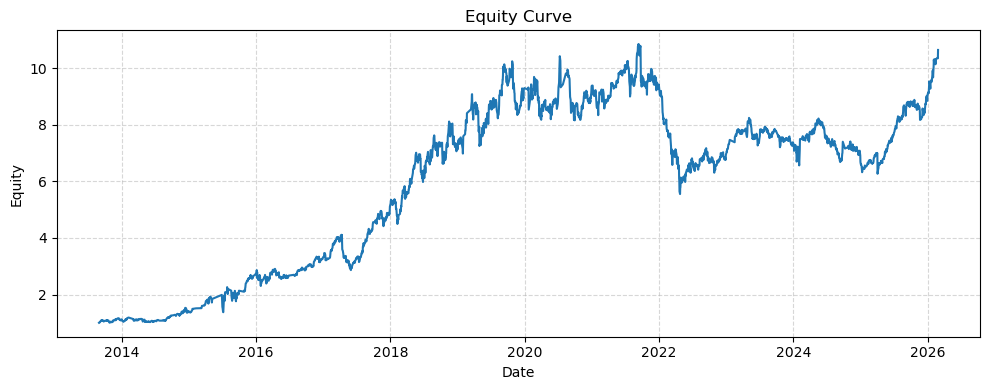

In [8]:
ann = 252
w_huber_rank = backtester.build_long_only_weights(S_huber, sample_mask, k=10, gross=1.0, min_names=10)
port_ret_huber_rank = (w_huber_rank * R_fwd_s.reindex(w_huber_rank.index)).sum(axis=1, min_count=1).dropna()
print(backtester.performance_summary(port_ret_huber_rank))
backtester.plot_equity_curve(port_ret_huber_rank)

## ICIR

Performance Summary
Periods             : 4330
Total Return        :  421.39%
CAGR                :   10.09%
Ann. Volatility     :   28.81%
Sharpe Ratio        :     0.35
Max Drawdown        :  -69.33%
Calmar Ratio        :     0.15
Hit Rate (p>0)      :   54.76%
None


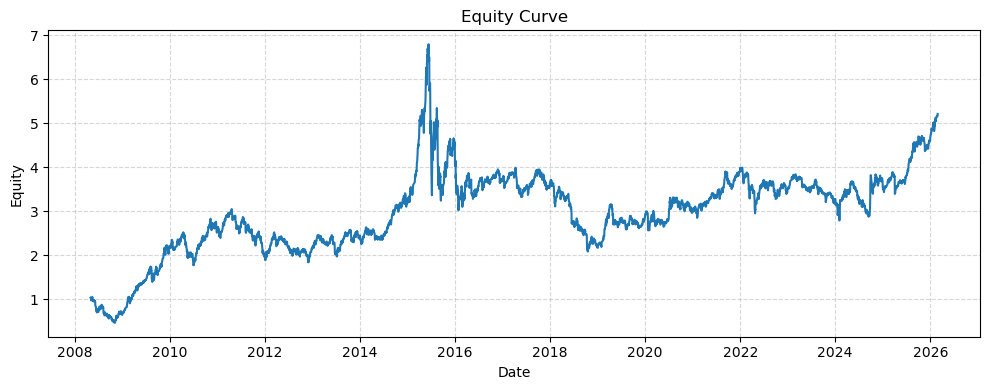

In [ ]:
w_rank = backtester.build_long_only_weights(S_icir, sample_mask, k=50, gross=1.0, min_names=10)
port_ret_rank = (w_rank * R_fwd_s.reindex(w_rank.index)).sum(axis=1, min_count=1).dropna()
print(backtester.performance_summary(port_ret_rank))
backtester.plot_equity_curve(port_ret_rank)

In [ ]:
stoxx_clean = _ensure_datetime_index(stoxx)

# Align
common = port_ret_rank.index.intersection(idx_ret.index)
sr = port_ret_rank.loc[common]
ir = idx_ret.loc[common]

eq_s = (1 + sr).cumprod()
eq_i = (1 + ir).cumprod()
eq_ex = (1 + (sr - ir)).cumprod()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(eq_s.index, eq_s.values, label="Ranking L/S equity", linewidth=2)
ax1.plot(eq_i.index, eq_i.values, label="Eurostoxx50 equity", linewidth=2)
ax1.set_title("Equity Curves: Ranking L/S vs Eurostoxx50")
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Growth (start=1)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(eq_ex.index, eq_ex.values, linestyle="--", linewidth=2, label="Excess equity")
ax2.set_ylabel("Excess Growth (start=1)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Rebalance Weekly

Performance Summary
Periods             : 2760
Total Return        :  100.17%
CAGR                :    6.54%
Ann. Volatility     :    5.81%
Sharpe Ratio        :     1.12
Max Drawdown        :  -13.59%
Calmar Ratio        :     0.48
Hit Rate (p>0)      :   54.20%
None


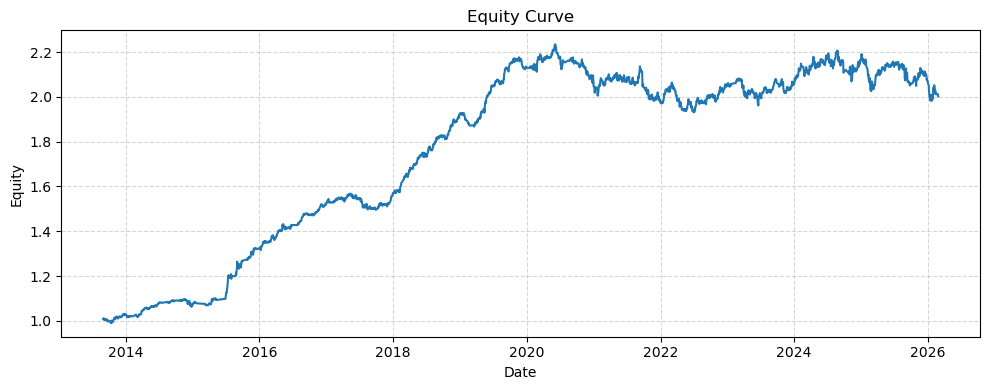

In [12]:
ann = 252
w_huber_week = backtester.build_top_bottom_weights_weekly(S_huber, sample_mask, k=100, gross=1.0, rebalance="W-FRI",min_names=10)
port_ret_huber_week = (w_huber_week * R_fwd_s.reindex(w_huber_week.index)).sum(axis=1, min_count=1).dropna()
turnover_huber_week = w_huber_week.diff().abs().sum(axis=1).reindex(port_ret_huber_week.index).fillna(0.0)
sharpe_huber_week = (port_ret_huber_week.mean() / port_ret_huber_week.std(ddof=1)) * np.sqrt(ann) if port_ret_huber_week.std(ddof=1) > 0 else np.nan
print(backtester.performance_summary(port_ret_huber_week))
backtester.plot_equity_curve(port_ret_huber_week)

Performance Summary
Periods             : 4325
Total Return        :  286.19%
CAGR                :    8.19%
Ann. Volatility     :    4.78%
Sharpe Ratio        :     1.71
Max Drawdown        :  -13.09%
Calmar Ratio        :     0.63
Hit Rate (p>0)      :   53.76%
None


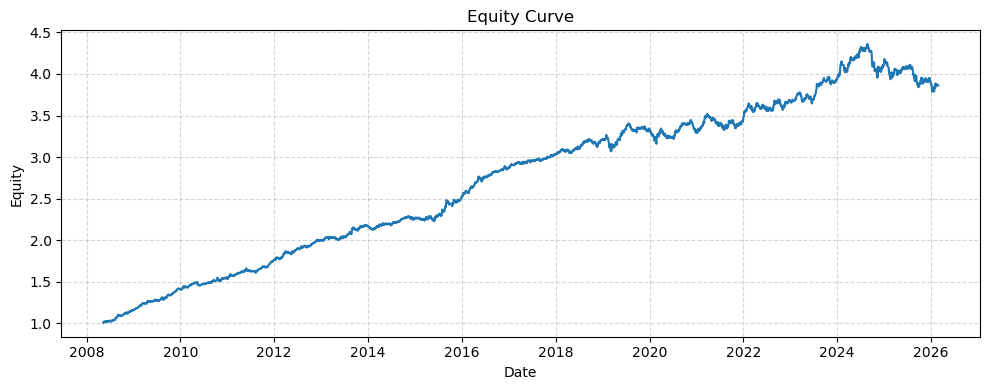

In [11]:
w_week = backtester.build_top_bottom_weights_weekly(S_icir, sample_mask,k=100, gross=1.0, rebalance="W-FRI", min_names=10)
port_ret_week = (w_week * R_fwd_s.reindex(w_week.index)).sum(axis=1, min_count=1).dropna()
turnover_week = w_week.diff().abs().sum(axis=1).reindex(port_ret_week.index).fillna(0.0)
sharpe_week = (port_ret_week.mean() / port_ret_week.std(ddof=1)) * np.sqrt(ann) if port_ret_week.std(ddof=1) > 0 else np.nan
print(backtester.performance_summary(port_ret_week))
backtester.plot_equity_curve(port_ret_week)

## 6.2 Tracking Optimization
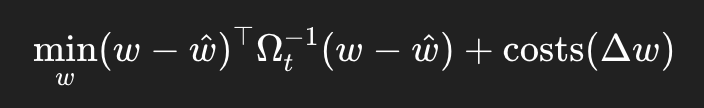

### Convert Score to Weights Panel

In [13]:
def score_to_w_hat(
    S: pd.DataFrame,
    tradable: pd.DataFrame,
    gross_target: float = 1.0,
    net_target: float = 0.0,
    winsor_q: float = 0.01,
    pos_limit: float = 0.06,
    min_names: int = 20,
) -> pd.DataFrame:
    S = S.where(tradable)
    W = []

    for dt in S.index:
        x = S.loc[dt].astype(float)
        m = x.notna()
        if m.sum() < min_names:
            W.append(pd.Series(0.0, index=S.columns, name=dt))
            continue

        xs = x[m]
        lo, hi = xs.quantile(winsor_q), xs.quantile(1 - winsor_q)
        xs = xs.clip(lo, hi)

        # net-neutral baseline
        xs = xs - xs.mean()
        if net_target != 0:
            xs = xs + float(net_target) / m.sum()

        # scale to gross_target
        gross = xs.abs().sum()
        if gross > 0:
            xs = xs * (gross_target / gross)

        # per-name cap + renormalize gross
        xs = xs.clip(-pos_limit, pos_limit)
        gross2 = xs.abs().sum()
        if gross2 > 0:
            xs = xs * (gross_target / gross2)

        w = pd.Series(0.0, index=S.columns, name=dt)
        w.loc[m] = xs
        W.append(w)

    return pd.DataFrame(W).sort_index()

w_hat = score_to_w_hat(S_icir, sample_mask, gross_target=1.0, net_target=0.0, pos_limit=0.06)
print("w_hat avg gross:", float(w_hat.abs().sum(axis=1).mean()), "avg net:", float(w_hat.sum(axis=1).mean()))

w_hat avg gross: 0.9997691064419303 avg net: -5.230968845950207e-19


### Building Omega(t)

In [78]:
def ewma_vol(ret: pd.DataFrame, halflife: int = 20, min_periods: int = 20) -> pd.DataFrame:
    """
    EWMA volatility per ticker.
    """
    lam = np.exp(np.log(0.5) / halflife)
    # pandas ewm uses alpha; alpha = 1-lam
    vol = ret.ewm(alpha=(1 - lam), adjust=False, min_periods=min_periods).std(bias=False)
    return vol

ret_1d = px_close.pct_change(1, fill_method=None)
vol = ewma_vol(ret_1d, halflife=20, min_periods=20).reindex(w_hat.index)
vol = vol.where(sample_mask).fillna(method="ffill")

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_40497/2829803386.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vol = vol.where(sample_mask).fillna(method="ffill")


### Execution: Optimizer Solved

In [79]:
def solve_tracking(
    w_hat_t: pd.Series,
    w_prev_t: pd.Series,
    vol_t: pd.Series,
    gross_max: float = 1.0,
    net_band: float = 0.02,
    pos_limit: float = 0.06,
    eta_turnover: float = 10.0,
):
    """
    Minimize sum_i ((w_i - w_hat_i)^2 / vol_i^2) + eta * ||w-w_prev||^2
    s.t. sum(w) in [-net_band, +net_band]
         sum(|w|) <= gross_max
         |w_i| <= pos_limit
    """
    tickers = w_hat_t.index
    w_hat_np = w_hat_t.values.astype(float)
    w_prev_np = w_prev_t.reindex(tickers).fillna(0.0).values.astype(float)

    # protect against zero vol
    v = vol_t.reindex(tickers).fillna(vol_t.median()).values.astype(float)
    v = np.where(v <= 1e-8, np.nanmedian(v[v > 1e-8]) if np.any(v > 1e-8) else 0.01, v)
    inv_var = 1.0 / (v ** 2)

    try:
        w = cp.Variable(len(tickers))
        obj = cp.sum(cp.multiply(inv_var, cp.square(w - w_hat_np))) + eta_turnover * cp.sum_squares(w - w_prev_np)

        cons = [
            cp.sum(w) <= net_band,
            cp.sum(w) >= -net_band,
            cp.norm1(w) <= gross_max,
            w <= pos_limit,
            w >= -pos_limit,
        ]

        prob = cp.Problem(cp.Minimize(obj), cons)
        prob.solve(solver=cp.OSQP, verbose=False)

        if w.value is None:
            raise RuntimeError("cvxpy failed to solve")

        return pd.Series(w.value, index=tickers)

    except Exception:
        # Fallback heuristic: partial move + projection to constraints
        w = 0.5 * w_prev_np + 0.5 * w_hat_np  # half-step
        w = np.clip(w, -pos_limit, pos_limit)

        # net band projection
        net = w.sum()
        if net > net_band:
            w -= (net - net_band) / len(w)
        elif net < -net_band:
            w -= (net + net_band) / len(w)

        # gross projection
        gross = np.sum(np.abs(w))
        if gross > gross_max and gross > 0:
            w *= gross_max / gross

        return pd.Series(w, index=tickers)

# Run daily execution
w_exec = pd.DataFrame(index=w_hat.index, columns=w_hat.columns, dtype=float)
w_prev = pd.Series(0.0, index=w_hat.columns)

for dt in w_hat.index:
    tradable_t = sample_mask.loc[dt]
    w_hat_t = w_hat.loc[dt].where(tradable_t).fillna(0.0)
    vol_t = vol.loc[dt].where(tradable_t)

    w_t = solve_tracking(
        w_hat_t=w_hat_t,
        w_prev_t=w_prev,
        vol_t=vol_t,
        gross_max=1.0,
        net_band=0.02,
        pos_limit=0.06,
        eta_turnover=10.0,
    )
    w_exec.loc[dt] = w_t
    w_prev = w_t

w_exec = w_exec.fillna(0.0)
print("w_exec avg gross:", float(w_exec.abs().sum(axis=1).mean()), "avg net:", float(w_exec.sum(axis=1).mean()))

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/probl

w_exec avg gross: 0.9977198636977834 avg net: -0.0002812579664313485


In [ ]:
MIN_DAYS_REQUIRED = 1100   # drop factors with less history in this window
MIN_ICIR = -0.02           # optional: drop extremely bad factors
LOOKBACK = 252
MIN_NAMES = 30
EPS = 1e-12

# Use the ic_by_alpha you already computed (daily IC series per factor)
# and the ic_table you displayed.

# ---- 1) choose factor set to include
good_factors = ic_table.loc[ic_table["n_days"] >= MIN_DAYS_REQUIRED, "alpha"].tolist()
# Optionally filter by ICIR too
good_factors = [a for a in good_factors if float(ic_table.set_index("alpha").loc[a, "icir"]) >= MIN_ICIR]

print("Using factors:", good_factors)

# rebuild stacked X_rank with only good factors
X_rank_g = stack_alpha_dict(alpha_rank, good_factors, R_fwd_s.index)

dates = X_rank_g.index.intersection(R_fwd_s.index)

def score_from_weights_and_signs(X_row: pd.Series, w: pd.Series, sgn: pd.Series) -> pd.Series:
    """Score = sum_k w_k * sgn_k * x_k. X_row index=(alpha,ticker)."""
    Xmat = X_row.unstack("alpha").reindex(columns=w.index).fillna(0.0)
    w_eff = (w * sgn).values
    return pd.Series(Xmat.values @ w_eff, index=Xmat.index)

# ---- 2) rolling ICIR weights + rolling sign
W = pd.DataFrame(index=dates, columns=good_factors, dtype=float)
SGN = pd.DataFrame(index=dates, columns=good_factors, dtype=float)

for i, t in enumerate(dates):
    past = dates[max(0, i-LOOKBACK):i]
    if len(past) < 60:
        continue

    w = {}
    sgn = {}
    for a in good_factors:
        s = ic_by_alpha[a].reindex(past).dropna()
        if len(s) < 40:
            w[a] = 0.0
            sgn[a] = 1.0
            continue

        mu = float(s.mean())
        sd = float(s.std(ddof=1))
        icir = mu / sd if sd > 0 else 0.0

        # sign-align using past mean IC
        sgn[a] = 1.0 if mu >= 0 else -1.0

        # ICIR weights: keep only positive ICIR contribution
        w[a] = max(0.0, float(icir))

    w = pd.Series(w).reindex(good_factors).fillna(0.0)
    sgn = pd.Series(sgn).reindex(good_factors).fillna(1.0)

    if w.sum() <= EPS:
        continue

    w = w / (w.abs().sum() + EPS)
    W.loc[t] = w
    SGN.loc[t] = sgn

W = W.dropna(how="all")
SGN = SGN.loc[W.index]

print("W shape:", W.shape, "SGN shape:", SGN.shape)

# ---- 3) compute scores
scores = []
for t in W.index:
    xrow = X_rank_g.loc[t]
    w = W.loc[t].astype(float)
    sgn = SGN.loc[t].astype(float)

    s = score_from_weights_and_signs(xrow, w, sgn)

    m = sample_mask.loc[t] & R_fwd_s.loc[t].notna()
    s = s.where(m)
    scores.append(s.rename(t))

S_combo = pd.DataFrame(scores).sort_index()

# ---- 4) evaluate IC
ic_combo = daily_ic_from_panels(S_combo, R_fwd_s, sample_mask, method="spearman", min_names=MIN_NAMES)
print("Sign+ICIR combo IC mean/std/ICIR:",
      float(ic_combo.mean()),
      float(ic_combo.std(ddof=1)),
      float(ic_combo.mean()/ic_combo.std(ddof=1)) if ic_combo.std(ddof=1)>0 else np.nan)
display(ic_combo.describe())

Using factors: ['alpha1', 'alpha2', 'alpha9', 'alpha12', 'alpha5', 'alpha13', 'alpha17', 'alpha3', 'alpha4']
W shape: (1212, 9) SGN shape: (1212, 9)
Sign+ICIR combo IC mean/std/ICIR: 0.023133208246419783 0.1798208029653207 0.12864589560797998


count    1212.000000
mean        0.023133
std         0.179821
min        -0.473636
25%        -0.099243
50%         0.027385
75%         0.144990
max         0.559796
dtype: float64

### Backtest

In [116]:
port_ret = (w_exec * R_fwd.reindex(w_exec.index)).sum(axis=1,min_count=1).dropna()
turnover = w_exec.diff().abs().sum(axis=1).fillna(0.0)

ann = 252
sharpe = (port_ret.mean() / port_ret.std(ddof=1)) * np.sqrt(ann) if port_ret.std(ddof=1) > 0 else np.nan

print(performance_summary(port_ret))

perf = pd.DataFrame({"port_ret": port_ret, "turnover": turnover.reindex(port_ret.index)})

===== Performance Summary =====
Periods             : 1211
Total Return        :   68.98%
CAGR                :   11.54%
Ann. Volatility     :    5.85%
Sharpe Ratio        :     1.97
Max Drawdown        :   -5.91%
Calmar Ratio        :     1.95
Hit Rate (p>0)      :   56.15%
None


Aligned period: 2020-05-22 to 2025-11-24 | #days: 1186


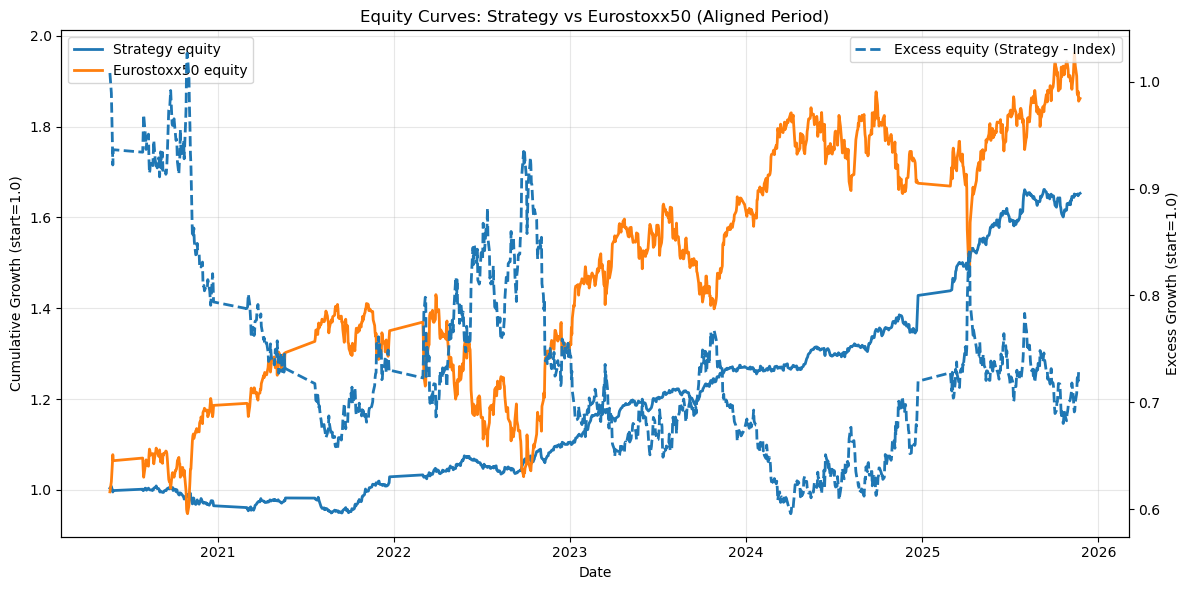

In [81]:
port_ret = _ensure_datetime_index(port_ret).dropna()
stoxx = _ensure_datetime_index(stoxx)

# ---- Pick the close column for index (adjust if yours differs) ----
# In your screenshot the close column is "收盘"
idx_px = stoxx["收盘"].astype(float)

# ---- Build index returns ----
idx_ret = idx_px.pct_change(fill_method=None).dropna()

# ---- Align date period (IMPORTANT) ----
common_idx = port_ret.index.intersection(idx_ret.index).sort_values()
port_ret_a = port_ret.reindex(common_idx).dropna()
idx_ret_a = idx_ret.reindex(port_ret_a.index).dropna()
common_idx = port_ret_a.index.intersection(idx_ret_a.index)
port_ret_a = port_ret_a.reindex(common_idx)
idx_ret_a = idx_ret_a.reindex(common_idx)

print("Aligned period:",
      common_idx.min().date(), "to", common_idx.max().date(),
      "| #days:", len(common_idx))

# ---- Equity curves ----
eq_strat = (1.0 + port_ret_a).cumprod()
eq_idx = (1.0 + idx_ret_a).cumprod()

# ---- Excess returns (daily and cumulative) ----
excess_ret = port_ret_a - idx_ret_a
eq_excess = (1.0 + excess_ret).cumprod()  # cumprod of daily excess (simple, common in practice)

# ---- Plot: Strategy vs Index + Excess (secondary axis) ----
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(eq_strat.index, eq_strat.values, label="Strategy equity", linewidth=2)
ax1.plot(eq_idx.index, eq_idx.values, label="Eurostoxx50 equity", linewidth=2)
ax1.set_title("Equity Curves: Strategy vs Eurostoxx50 (Aligned Period)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Growth (start=1.0)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(eq_excess.index, eq_excess.values, label="Excess equity (Strategy - Index)", linestyle="--", linewidth=2)
ax2.set_ylabel("Excess Growth (start=1.0)")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [25]:
performance_summary(idx_ret_a)

===== Performance Summary =====
Periods             : 1186
Total Return        :   86.18%
CAGR                :   14.12%
Ann. Volatility     :   20.47%
Sharpe Ratio        :     0.69
Max Drawdown        :  -28.03%
Calmar Ratio        :     0.50
Hit Rate (p>0)      :   53.71%


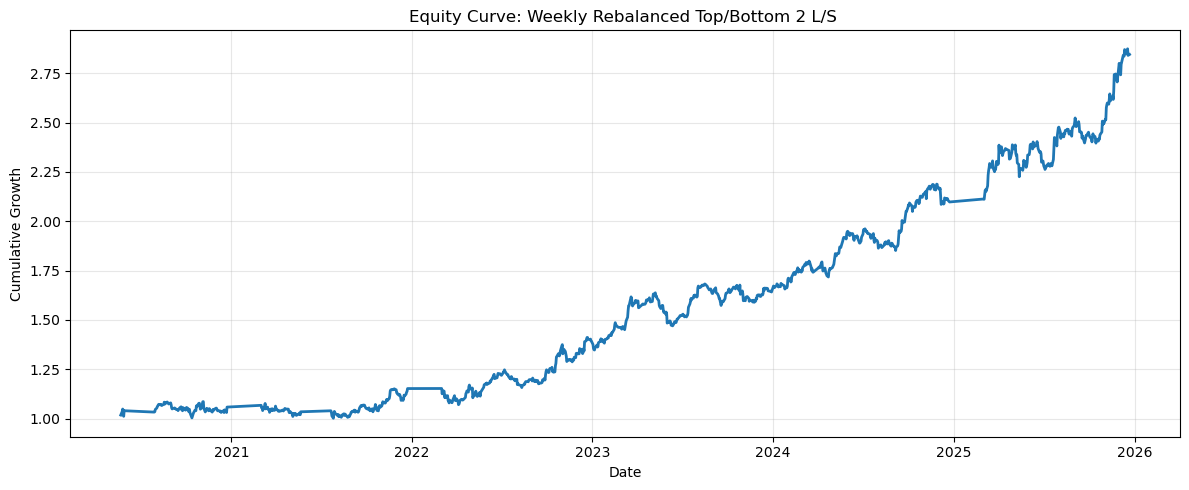

In [112]:
plt.figure(figsize=(12,5))
plt.plot(eq_week.index, eq_week.values, linewidth=2)
plt.title("Equity Curve: Weekly Rebalanced Top/Bottom 2 L/S ")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
w_rank.to_csv('/Users/apple/Desktop/Rank5_Weights.csv')